In [1]:
# task 1
import pandas as pd
train = pd.read_csv("https://raw.githubusercontent.com/blacktreeM/econ/refs/heads/main/walmart_train.csv")
train.head()

,date,store_nbr,item_nbr,units
0,2012-01-01,1,9,29
1,2012-01-01,1,28,2
2,2012-01-01,1,40,0
3,2012-01-01,1,47,0
4,2012-01-01,1,51,1


In [3]:
print(train.columns.tolist())

['date', 'store_nbr', 'item_nbr', 'units']


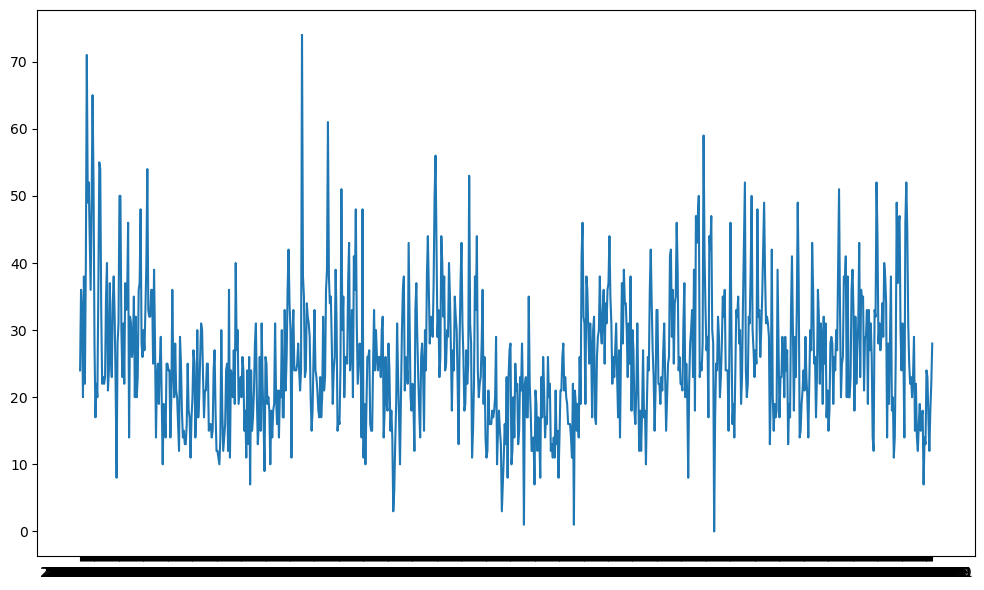

In [8]:
# task 2
store = 5
item = 16

fig = plt.figure(figsize=(10, 6))
ax1 = fig.add_subplot(1, 1, 1)  # 1 plot, normal size

# Filter the DataFrame correctly using boolean indexing
temp = ax1.plot(
    train.loc[(train['store_nbr'] == store) & (train['item_nbr'] == item), 'date'],
    train.loc[(train['store_nbr'] == store) & (train['item_nbr'] == item), 'units']
)

plt.tight_layout()
plt.show()

In [12]:
# task 3
df = train

df['date'] = pd.to_datetime(df['date']) # convert to datetime
df['year'] = df['date'].dt.year # year col
df['month'] = df['date'].dt.month # month col
df['day'] = df['date'].dt.day_name() # day col

In [15]:
# task 4
import statsmodels.formula.api as smf

store = 5
item = 16

# Filter for store 5, item 16
df_filtered = df[(df['store_nbr'] == store) & (df['item_nbr'] == item)].copy()

# Fit model
formula = 'units ~ year + month + day'
my_model = smf.ols(formula, data=df_filtered).fit()

print(my_model.summary())

# Create predicted values and add as new column
df_filtered['predicted_units'] = my_model.predict(df_filtered)

print(df_filtered[['date', 'units', 'predicted_units']].head(10))

                            OLS Regression Results                            
Dep. Variable:                  units   R-squared:                       0.193
Model:                            OLS   Adj. R-squared:                  0.185
Method:                 Least Squares   F-statistic:                     26.20
Date:                Mon, 30 Mar 2026   Prob (F-statistic):           1.57e-36
Time:                        09:49:12   Log-Likelihood:                -3210.9
No. Observations:                 888   AIC:                             6440.
Df Residuals:                     879   BIC:                             6483.
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept        -1622.4176    771.722  

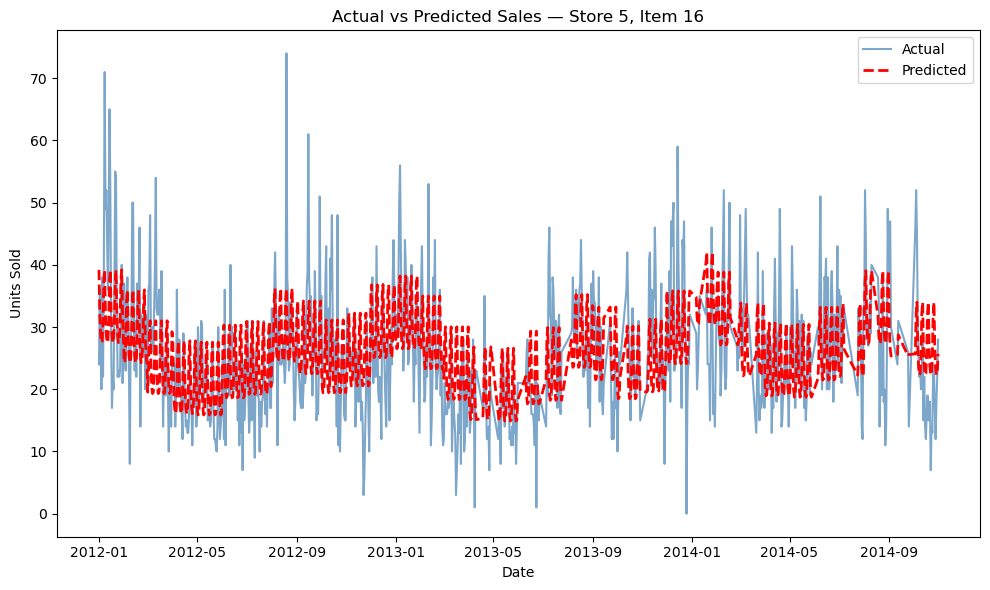

In [17]:
# task 4
import statsmodels.formula.api as smf

store = 5
item = 16

# Filter for store 5, item 16
df_filtered = df[(df['store_nbr'] == store) & (df['item_nbr'] == item)].copy()

# Fit model
formula = 'units ~C(year) + C(month) + day' # treat year and month as category "C()"
my_model = smf.ols(formula, data=df_filtered).fit()

# Create predicted values and add as new column
df_filtered['predicted_units'] = my_model.predict(df_filtered)

# Plot actual vs predicted
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(df_filtered['date'], df_filtered['units'], 
        label='Actual', color='steelblue', alpha=0.7)
ax.plot(df_filtered['date'], df_filtered['predicted_units'], 
        label='Predicted', color='red', linestyle='--', linewidth=2)

ax.set_title(f'Actual vs Predicted Sales — Store {store}, Item {item}')
ax.set_xlabel('Date')
ax.set_ylabel('Units Sold')
ax.legend()

plt.tight_layout()
plt.show()